# **GALAXY CLASSIFICATION**

### Import libraries for data handling and visualization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load the training dataset into a DataFrame

In [2]:
df_train = pd.read_csv('/kaggle/input/training-csv/5x127x127_training_with_morphology.csv')
df_train

,coord,dec,g_central_image_pop_10px_rad,g_central_image_pop_15px_rad,g_central_image_pop_5px_rad,g_cmodel_mag,g_cmodel_magsigma,g_ellipticity,g_half_light_radius,g_isophotal_area,...,z_cmodel_magsigma,z_ellipticity,z_half_light_radius,z_isophotal_area,z_major_axis,z_minor_axis,z_peak_surface_brightness,z_petro_rad,z_pos_angle,z_sersic_index
0,"b'(179028.65625, 99644.3671875, -23767.86328125)'",-6.616883,1,1,1,20.162785,0.002381,0.026,2.085,177.0,...,0.002657,0.076,2.186,127.0,2.112,1.951,-8.0189,4.62,63.61,1.146
1,"b'(178895.09375, 99811.6484375, -24069.6933593...",-6.701294,1,1,1,20.320715,0.005252,0.143,5.986,327.0,...,0.002538,0.129,6.270,547.0,5.043,4.393,-7.6611,6.60,74.63,1.576
2,"b'(178918, 99992.578125, -23130.162109375)'",-6.438588,1,1,1,21.629736,0.013312,0.068,7.286,162.0,...,0.002606,0.082,6.687,611.0,5.370,4.932,-7.2715,7.26,83.77,2.096
3,"b'(179111.03125, 99659.84375, -23072.220703125)'",-6.422391,1,1,1,21.448307,0.004646,0.012,2.108,109.0,...,0.005510,0.023,2.966,121.0,2.323,2.269,-6.8408,6.60,29.82,1.943
4,"b'(178849.21875, 99990.828125, -23663.556640625)'",-6.587715,1,1,1,21.827169,0.010504,0.150,4.552,113.0,...,0.003021,0.256,5.264,401.0,4.652,3.463,-7.2982,7.26,66.69,2.187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204568,"b'(-103042.1796875, -68623.8203125, 164979.546...",53.115152,1,1,1,22.603470,0.013377,0.127,5.140,157.0,...,0.005172,0.097,3.910,199.0,3.176,2.869,-6.3175,5.94,52.46,1.300
204569,"b'(-102705.109375, -69098.7890625, 164991.4843...",53.120677,1,2,1,21.211262,0.002013,0.050,2.523,216.0,...,0.004888,0.031,2.441,95.0,2.049,1.985,-6.3903,5.28,86.33,0.955
204570,"b'(-102906.5, -68952.8125, 164927.046875)'",53.090862,1,1,1,19.315403,0.001800,0.133,6.529,864.0,...,0.000825,0.121,6.587,1361.0,6.917,6.083,-8.4032,5.28,-48.55,1.832
204571,"b'(-102564.9296875, -69022.4609375, 165110.578...",53.175836,1,1,1,22.623613,0.010091,0.298,4.448,144.0,...,0.014664,0.292,4.161,106.0,3.060,2.166,-4.6701,7.26,76.00,0.571


### Checking if common object IDs between train and validation sets

In [3]:
df_val = pd.read_csv('/kaggle/input/validation-csvv/5x127x127_validation_with_morphology.csv')

# Common column name
key = 'object_id'

# Find common IDs
common_ids = set(df_train[key]).intersection(set(df_val[key]))

print(f"Number of common samples: {len(common_ids)}")
if common_ids:
    print("Example common IDs:", list(common_ids)[:5])
else:
    print("No common samples found.")

Number of common samples: 0
No common samples found.


### Load the testing dataset into a DataFrame

In [4]:
df_test = pd.read_csv("/kaggle/input/testing-csv/5x127x127_testing_with_morphology.csv")

In [5]:
df_train.columns

Index(['coord', 'dec', 'g_central_image_pop_10px_rad',
       'g_central_image_pop_15px_rad', 'g_central_image_pop_5px_rad',
       'g_cmodel_mag', 'g_cmodel_magsigma', 'g_ellipticity',
       'g_half_light_radius', 'g_isophotal_area', 'g_major_axis',
       'g_minor_axis', 'g_peak_surface_brightness', 'g_petro_rad',
       'g_pos_angle', 'g_sersic_index', 'i_central_image_pop_10px_rad',
       'i_central_image_pop_15px_rad', 'i_central_image_pop_5px_rad',
       'i_cmodel_mag', 'i_cmodel_magsigma', 'i_ellipticity',
       'i_half_light_radius', 'i_isophotal_area', 'i_major_axis',
       'i_minor_axis', 'i_peak_surface_brightness', 'i_petro_rad',
       'i_pos_angle', 'i_sersic_index', 'object_id',
       'r_central_image_pop_10px_rad', 'r_central_image_pop_15px_rad',
       'r_central_image_pop_5px_rad', 'r_cmodel_mag', 'r_cmodel_magsigma',
       'r_ellipticity', 'r_half_light_radius', 'r_isophotal_area',
       'r_major_axis', 'r_minor_axis', 'r_peak_surface_brightness',
       'r_p

### Checking for null values

In [6]:
df_train.isnull().sum()

coord                           0
dec                             0
g_central_image_pop_10px_rad    0
g_central_image_pop_15px_rad    0
g_central_image_pop_5px_rad     0
                               ..
z_minor_axis                    0
z_peak_surface_brightness       0
z_petro_rad                     0
z_pos_angle                     0
z_sersic_index                  0
Length: 84, dtype: int64

In [7]:
df_train['skymap_id'].value_counts()

skymap_id
169730504    1024
169730405    1020
169730603     734
85230304      695
169730602     684
             ... 
91090804        1
158170807       1
91100003        1
158180002       1
158250005       1
Name: count, Length: 25141, dtype: int64

In [8]:
df_train['skymap_id'].describe()

count    2.045730e+05
mean     1.017376e+08
std      2.176291e+07
min      8.278000e+07
25%      9.327030e+07
50%      9.571010e+07
75%      9.807010e+07
max      1.697308e+08
Name: skymap_id, dtype: float64

### Plotting the Scatter plots for Skymap ids

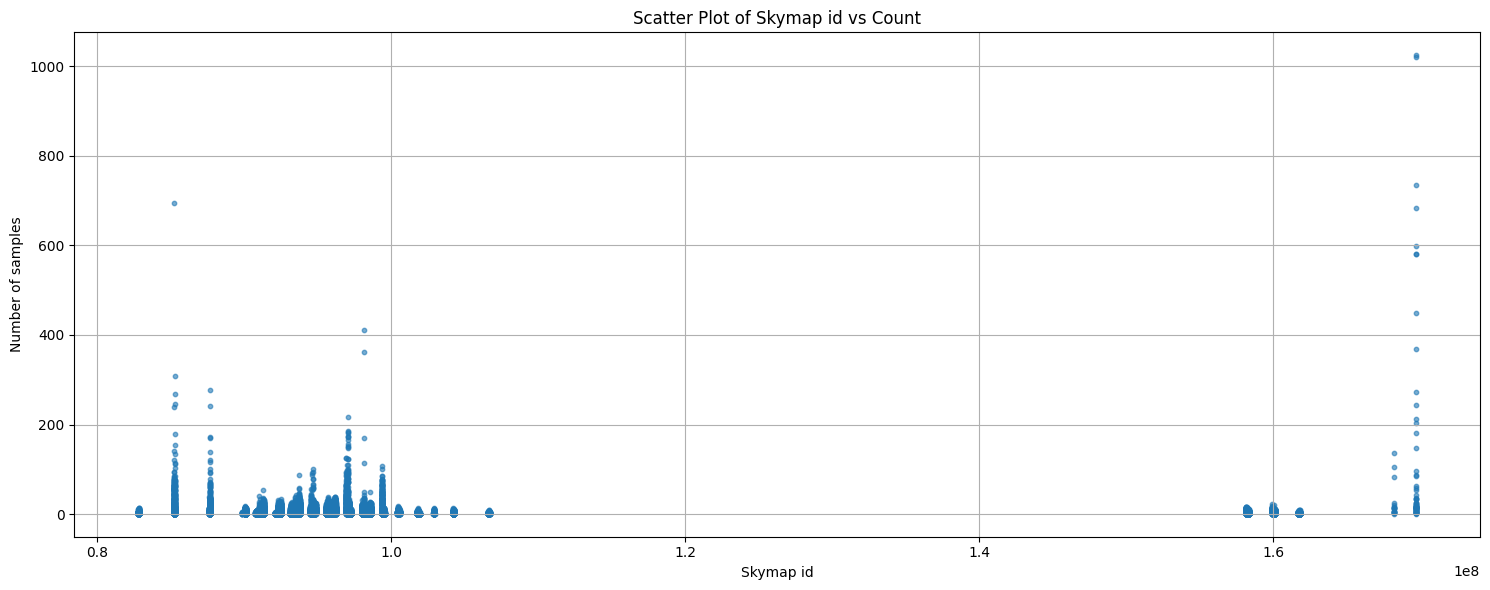

In [9]:
# Count number of samples per skymap_id and sort by ID
skymap_counts = df_train['skymap_id'].value_counts().sort_index()

# Plotting the distribution as a scatter plot
plt.figure(figsize=(15, 6))
plt.scatter(skymap_counts.index, skymap_counts.values, s=10, alpha=0.6)

plt.title('Scatter Plot of Skymap id vs Count')
plt.xlabel('Skymap id')
plt.ylabel('Number of samples')
plt.grid(True)
plt.tight_layout()
plt.show()

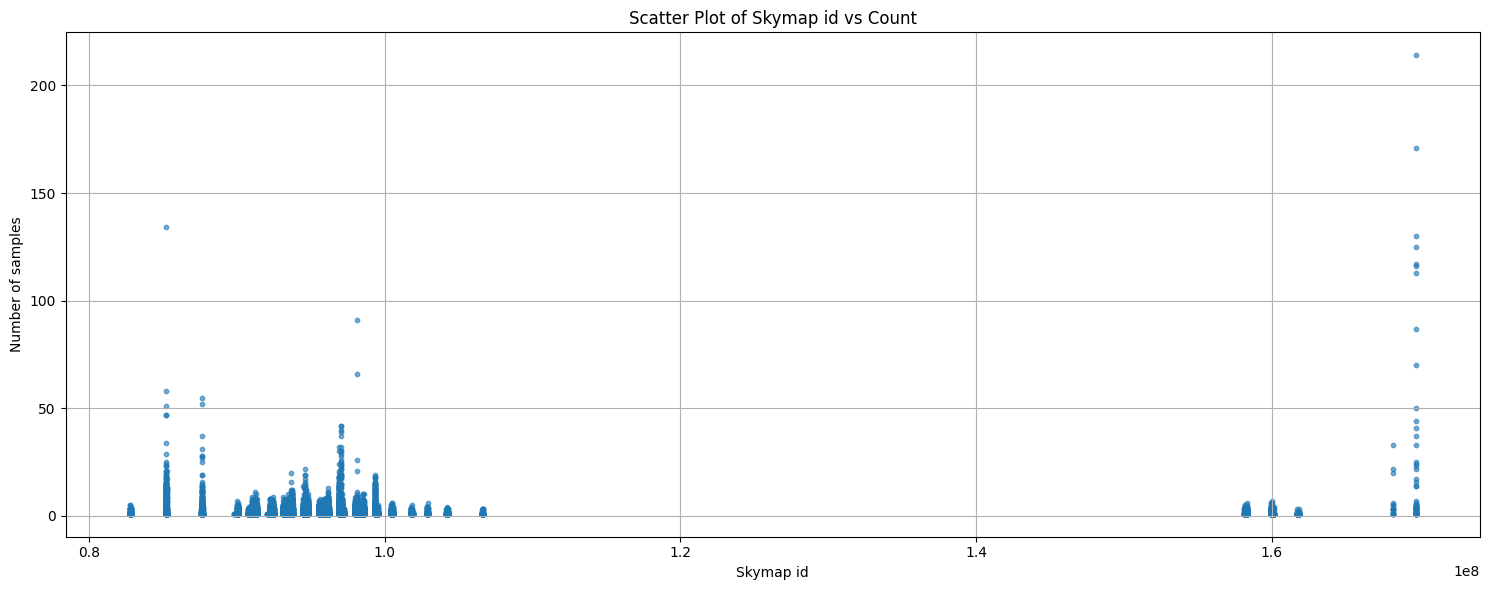

In [10]:
# Count number of samples per skymap_id and sort by ID
skymap_counts1 = df_val['skymap_id'].value_counts().sort_index()

# Plotting the distribution as a scatter plot
plt.figure(figsize=(15, 6))
plt.scatter(skymap_counts1.index, skymap_counts1.values, s=10, alpha=0.6)

plt.title('Scatter Plot of Skymap id vs Count')
plt.xlabel('Skymap id')
plt.ylabel('Number of samples')
plt.grid(True)
plt.tight_layout()
plt.show()

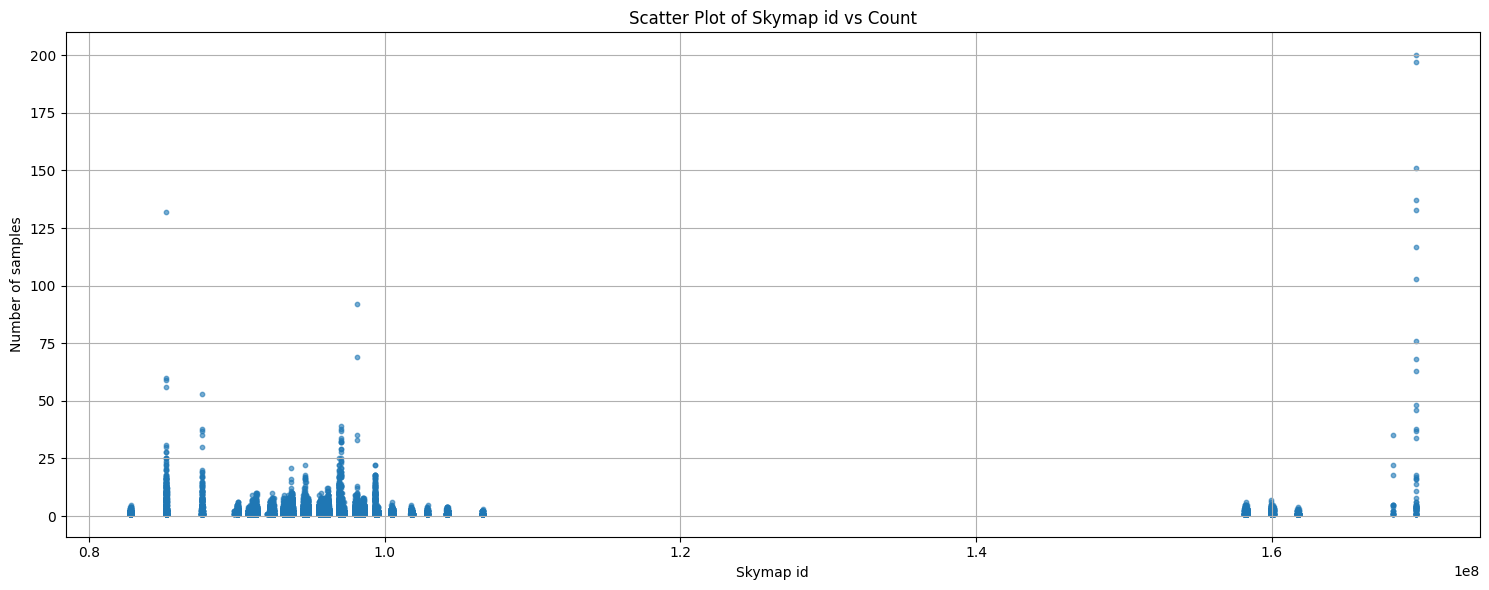

In [11]:
# Count number of samples per skymap_id and sort by ID
skymap_counts2 = df_test['skymap_id'].value_counts().sort_index()

# Plotting the distribution as a scatter plot
plt.figure(figsize=(15, 6))
plt.scatter(skymap_counts2.index, skymap_counts2.values, s=10, alpha=0.6)

plt.title('Scatter Plot of Skymap id vs Count')
plt.xlabel('Skymap id')
plt.ylabel('Number of samples')
plt.grid(True)
plt.tight_layout()
plt.show()

### Converting object dtypes to float or int

Features which have object data types 

In [12]:
object_column_names = df_train.select_dtypes(include='object').columns
object_column_names

Index(['coord', 'specz_name'], dtype='object')

Function to convert 'coord' to float 

In [13]:
# Function to parse coordinate string into x, y, z floats
def parse_coord(coord_str):
    try:
        clean = coord_str.strip("b'").strip("()")  # remove unwanted characters
        x_str, y_str, z_str = clean.split(',')
        return float(x_str), float(y_str), float(z_str)
    except Exception:
        return None, None, None  # return Nones if parsing fails

# Apply the parsing function and expand into 3 new columns
df_train[['coord_x', 'coord_y', 'coord_z']] = df_train['coord'].apply(parse_coord).apply(pd.Series)

In [14]:
# Similarly applying to validation and testing data set
df_val[['coord_x', 'coord_y', 'coord_z']] = df_val['coord'].apply(parse_coord).apply(pd.Series)

df_test[['coord_x', 'coord_y', 'coord_z']] = df_test['coord'].apply(parse_coord).apply(pd.Series)

In [15]:
df_train['specz_name']

0         b'SDSS-DR12-1237679340566282311'
1         b'SDSS-DR12-1237679439348826794'
2         b'SDSS-DR12-1237679340566282837'
3         b'SDSS-DR12-1237679439885697326'
4         b'SDSS-DR12-1237679340566282840'
                        ...               
204568    b'SDSS-DR12-1237661416602272099'
204569    b'SDSS-DR12-1237661416602337472'
204570    b'SDSS-DR12-1237661416602271803'
204571    b'SDSS-DR12-1237661416602337573'
204572    b'SDSS-DR12-1237661416602272090'
Name: specz_name, Length: 204573, dtype: object

Function to convert 'specz_name' to float

In [16]:
import re

# Extract numeric ID from a messy string or byte input
def extract_specz_id(x):
    try:
        if isinstance(x, bytes):
            x = x.decode('utf-8')  # decode bytes to string

        x_clean = x.strip().strip("'\"~")  # remove quotes/tilde

        # Find all numeric parts in the string
        numbers = re.findall(r'\d+', x_clean)

        if not numbers:
            raise ValueError("No numeric ID found")

        return int(max(numbers, key=int))  # return largest number found

    except Exception as e:
        print(f"[extract_specz_id] Error processing '{x}': {e}")
        return None

In [17]:
# Applying this functions to all three data sets
df_train['specz_id'] = df_train['specz_name'].apply(extract_specz_id)

df_val['specz_id'] = df_val['specz_name'].apply(extract_specz_id)

df_test['specz_id'] = df_test['specz_name'].apply(extract_specz_id)

In [18]:
df_train['specz_id'].head()

0    1237679340566282311
1    1237679439348826794
2    1237679340566282837
3    1237679439885697326
4    1237679340566282840
Name: specz_id, dtype: uint64

In [19]:
# Drop old columns from all three data sets
df_train1 = df_train.drop(['coord', 'specz_name'], axis=1)

df_val1 = df_val.drop(['coord', 'specz_name'], axis=1)

df_test1 = df_test.drop(['coord', 'specz_name'], axis=1)

In [20]:
df_train1.select_dtypes(include='object').columns

Index([], dtype='object')

In [21]:
df_train1.columns

Index(['dec', 'g_central_image_pop_10px_rad', 'g_central_image_pop_15px_rad',
       'g_central_image_pop_5px_rad', 'g_cmodel_mag', 'g_cmodel_magsigma',
       'g_ellipticity', 'g_half_light_radius', 'g_isophotal_area',
       'g_major_axis', 'g_minor_axis', 'g_peak_surface_brightness',
       'g_petro_rad', 'g_pos_angle', 'g_sersic_index',
       'i_central_image_pop_10px_rad', 'i_central_image_pop_15px_rad',
       'i_central_image_pop_5px_rad', 'i_cmodel_mag', 'i_cmodel_magsigma',
       'i_ellipticity', 'i_half_light_radius', 'i_isophotal_area',
       'i_major_axis', 'i_minor_axis', 'i_peak_surface_brightness',
       'i_petro_rad', 'i_pos_angle', 'i_sersic_index', 'object_id',
       'r_central_image_pop_10px_rad', 'r_central_image_pop_15px_rad',
       'r_central_image_pop_5px_rad', 'r_cmodel_mag', 'r_cmodel_magsigma',
       'r_ellipticity', 'r_half_light_radius', 'r_isophotal_area',
       'r_major_axis', 'r_minor_axis', 'r_peak_surface_brightness',
       'r_petro_rad', 'r_po

### Grouping Features by Filter Prefix to reduce number of features and prevent overfitting

In [22]:
from collections import defaultdict

columns = df_train1.columns  # All column names
filters = ['g_', 'r_', 'i_', 'z_', 'y_']  # Filter prefixes

grouped = defaultdict(list)
ungrouped = []

# Group columns by removing filter prefix
for col in columns:
    matched = False
    for f in filters:
        if col.startswith(f):
            base = col[len(f):] 
            grouped[base].append(col)
            matched = True
            break
    if not matched:
        ungrouped.append(col)

# Display grouped filter-based columns
print("Grouped features (by base name):")
for base, variants in grouped.items():
    print(f"{base}: {variants}\n")

print("\nUngrouped features:")
print(ungrouped)

Grouped features (by base name):
central_image_pop_10px_rad: ['g_central_image_pop_10px_rad', 'i_central_image_pop_10px_rad', 'r_central_image_pop_10px_rad', 'y_central_image_pop_10px_rad', 'z_central_image_pop_10px_rad']

central_image_pop_15px_rad: ['g_central_image_pop_15px_rad', 'i_central_image_pop_15px_rad', 'r_central_image_pop_15px_rad', 'y_central_image_pop_15px_rad', 'z_central_image_pop_15px_rad']

central_image_pop_5px_rad: ['g_central_image_pop_5px_rad', 'i_central_image_pop_5px_rad', 'r_central_image_pop_5px_rad', 'y_central_image_pop_5px_rad', 'z_central_image_pop_5px_rad']

cmodel_mag: ['g_cmodel_mag', 'i_cmodel_mag', 'r_cmodel_mag', 'y_cmodel_mag', 'z_cmodel_mag']

cmodel_magsigma: ['g_cmodel_magsigma', 'i_cmodel_magsigma', 'r_cmodel_magsigma', 'y_cmodel_magsigma', 'z_cmodel_magsigma']

ellipticity: ['g_ellipticity', 'i_ellipticity', 'r_ellipticity', 'y_ellipticity', 'z_ellipticity']

half_light_radius: ['g_half_light_radius', 'i_half_light_radius', 'r_half_light_radiu

### Function to group these features together 

In [23]:
from collections import defaultdict

# Define photometric filter prefixes
filters = ['g_', 'r_', 'i_', 'z_', 'y_']

# Group columns by removing filter prefix
grouped = defaultdict(list)
ungrouped = []

for col in df_train1.columns:
    matched = False
    for f in filters:
        if col.startswith(f):
            base = col[len(f):]
            grouped[base].append(col)
            matched = True
            break
    if not matched:
        ungrouped.append(col)

all_grouped_columns = []

# Create new columns with grouped list of values per base feature
for base, variant_cols in grouped.items():
    ordered_cols = [f + base for f in filters if f + base in df_train1.columns]
    if ordered_cols:
        df_train1[base + '_grouped'] = df_train1[ordered_cols].values.tolist()
    all_grouped_columns.extend(ordered_cols)

Similarly applying this function to train and val data set

In [24]:
# Group columns by removing filter prefix
grouped1 = defaultdict(list)
ungrouped1 = []

for col in df_val1.columns:
    matched = False
    for f in filters:
        if col.startswith(f):
            base = col[len(f):]
            grouped1[base].append(col)
            matched = True
            break
    if not matched:
        ungrouped1.append(col)

all_grouped_columns1 = []

# Create new columns with grouped list of values per base feature
for base, variant_cols in grouped1.items():
    ordered_cols1 = [f + base for f in filters if f + base in df_val1.columns]
    if ordered_cols1:  
        df_val1[base + '_grouped'] = df_val1[ordered_cols1].values.tolist()
    all_grouped_columns1.extend(ordered_cols1)

In [25]:
# Group columns by removing filter prefix
grouped2 = defaultdict(list)
ungrouped2 = []

for col in df_test1.columns:
    matched = False
    for f in filters:
        if col.startswith(f):
            base = col[len(f):]
            grouped2[base].append(col)
            matched = True
            break
    if not matched:
        ungrouped2.append(col)

all_grouped_columns2 = []

# Create new columns with grouped list of values per base feature
for base, variant_cols in grouped2.items():
    ordered_cols2 = [f + base for f in filters if f + base in df_test1.columns]
    if ordered_cols2:  
        df_test1[base + '_grouped'] = df_test1[ordered_cols2].values.tolist()
    all_grouped_columns2.extend(ordered_cols2)

### Creating Overlapping Color Feature Groups

In [26]:
# Mapping for overlapping color indices to broader grouped features
color_map = {
    'r_color': ['g_r_color', 'r_i_color'],
    'i_color': ['r_i_color', 'i_z_color'],
    'z_color': ['i_z_color', 'z_y_color'],
    'y_color': ['z_y_color', 'y_r_color']
}

# Create grouped color features by combining available source columns
for new_col, source_cols in color_map.items():
    existing = [col for col in source_cols if col in df_train1.columns]
    if existing:
        df_train1[new_col + '_grouped'] = df_train1[existing].values.tolist()
        all_grouped_columns.extend(existing)

In [27]:
# For Validaion Dataset
for new_col, source_cols in color_map.items():
    existing1 = [col for col in source_cols if col in df_val1.columns]
    if existing1:
        df_val1[new_col + '_grouped'] = df_val1[existing1].values.tolist()
        all_grouped_columns1.extend(existing1)

In [28]:
# For testing Dataset
for new_col, source_cols in color_map.items():
    existing2 = [col for col in source_cols if col in df_test1.columns]
    if existing2:
        df_test1[new_col + '_grouped'] = df_test1[existing2].values.tolist()
        all_grouped_columns2.extend(existing2)

### Listing all these newly created features

In [29]:
# List all newly created grouped columns i.e. ending with '_grouped'
grouped_cols = [col for col in df_train1.columns if col.endswith('_grouped')]

print("Grouped columns created:")
print(grouped_cols)

Grouped columns created:
['central_image_pop_10px_rad_grouped', 'central_image_pop_15px_rad_grouped', 'central_image_pop_5px_rad_grouped', 'cmodel_mag_grouped', 'cmodel_magsigma_grouped', 'ellipticity_grouped', 'half_light_radius_grouped', 'isophotal_area_grouped', 'major_axis_grouped', 'minor_axis_grouped', 'peak_surface_brightness_grouped', 'petro_rad_grouped', 'pos_angle_grouped', 'sersic_index_grouped', 'coord_grouped']


In [30]:
grouped_cols1 = [col for col in df_val1.columns if col.endswith('_grouped')]
print("Grouped columns created:")
print(grouped_cols1)

Grouped columns created:
['central_image_pop_10px_rad_grouped', 'central_image_pop_15px_rad_grouped', 'central_image_pop_5px_rad_grouped', 'cmodel_mag_grouped', 'cmodel_magsigma_grouped', 'ellipticity_grouped', 'half_light_radius_grouped', 'isophotal_area_grouped', 'major_axis_grouped', 'minor_axis_grouped', 'peak_surface_brightness_grouped', 'petro_rad_grouped', 'pos_angle_grouped', 'sersic_index_grouped', 'coord_grouped']


In [31]:
grouped_cols2 = [col for col in df_test1.columns if col.endswith('_grouped')]
print("Grouped columns created:")
print(grouped_cols2)

Grouped columns created:
['central_image_pop_10px_rad_grouped', 'central_image_pop_15px_rad_grouped', 'central_image_pop_5px_rad_grouped', 'cmodel_mag_grouped', 'cmodel_magsigma_grouped', 'ellipticity_grouped', 'half_light_radius_grouped', 'isophotal_area_grouped', 'major_axis_grouped', 'minor_axis_grouped', 'peak_surface_brightness_grouped', 'petro_rad_grouped', 'pos_angle_grouped', 'sersic_index_grouped', 'coord_grouped']


In [32]:
# Drop old columns from all three data sets

df_train2 = df_train1.drop(columns=all_grouped_columns)
df_val2 = df_val1.drop(columns=all_grouped_columns1)
df_test2 = df_test1.drop(columns=all_grouped_columns2)

In [33]:
df_train2.columns

Index(['dec', 'object_id', 'ra', 'skymap_id', 'specz_dec',
       'specz_flag_homogeneous', 'specz_mag_i', 'specz_ra', 'specz_redshift',
       'specz_redshift_err', 'x_coord', 'coord_x', 'coord_y', 'coord_z',
       'specz_id', 'central_image_pop_10px_rad_grouped',
       'central_image_pop_15px_rad_grouped',
       'central_image_pop_5px_rad_grouped', 'cmodel_mag_grouped',
       'cmodel_magsigma_grouped', 'ellipticity_grouped',
       'half_light_radius_grouped', 'isophotal_area_grouped',
       'major_axis_grouped', 'minor_axis_grouped',
       'peak_surface_brightness_grouped', 'petro_rad_grouped',
       'pos_angle_grouped', 'sersic_index_grouped', 'coord_grouped'],
      dtype='object')

### Grouping Spectroscopic features together

In [34]:
# Select key spectroscopic features to group together
specz_columns = [
    'specz_ra', 'specz_dec', 'specz_redshift',
    'specz_redshift_err', 'specz_mag_i', 'specz_flag_homogeneous'
]

# Combine selected specz columns into a single grouped list column
df_train2['specz_grouped'] = df_train2[specz_columns].values.tolist()

In [35]:
# For val
df_val2['specz_grouped'] = df_val2[specz_columns].values.tolist()

# For test
df_test2['specz_grouped'] = df_test2[specz_columns].values.tolist()

Droping old columns which are now grouped

In [36]:
df_train3 = df_train2.drop([
    'specz_ra', 'specz_dec', 'specz_redshift',
    'specz_redshift_err', 'specz_mag_i', 'specz_flag_homogeneous'
], axis=1)

In [37]:
df_val3 = df_val2.drop([
    'specz_ra', 'specz_dec', 'specz_redshift',
    'specz_redshift_err', 'specz_mag_i', 'specz_flag_homogeneous'
], axis=1)

In [38]:
df_test3 = df_test2.drop([
    'specz_ra', 'specz_dec', 'specz_redshift',
    'specz_redshift_err', 'specz_mag_i', 'specz_flag_homogeneous'
], axis=1)

In [39]:
df_train3.columns

Index(['dec', 'object_id', 'ra', 'skymap_id', 'x_coord', 'coord_x', 'coord_y',
       'coord_z', 'specz_id', 'central_image_pop_10px_rad_grouped',
       'central_image_pop_15px_rad_grouped',
       'central_image_pop_5px_rad_grouped', 'cmodel_mag_grouped',
       'cmodel_magsigma_grouped', 'ellipticity_grouped',
       'half_light_radius_grouped', 'isophotal_area_grouped',
       'major_axis_grouped', 'minor_axis_grouped',
       'peak_surface_brightness_grouped', 'petro_rad_grouped',
       'pos_angle_grouped', 'sersic_index_grouped', 'coord_grouped',
       'specz_grouped'],
      dtype='object')

In [40]:
# Just to confirm whether they are same or not
df_train3[['x_coord', 'coord_x']]

,x_coord,coord_x
0,60.3504,179028.656250
1,60.6967,178895.093750
2,60.7617,178918.000000
3,60.1416,179111.031250
4,60.9256,178849.218750
...,...,...
204568,59.6986,-103042.179688
204569,61.6153,-102705.109375
204570,59.4535,-102906.500000
204571,61.3318,-102564.929688


### Combining all 3D coordinates in one feature column

In [41]:
# Compute radial distance from (0, 0, 0) using 3D coordinates
df_train3['r_coord'] = np.sqrt(df_train3['coord_x']**2 + df_train3['coord_y']**2 + df_train3['coord_z']**2)

df_val3['r_coord'] = np.sqrt(df_val3['coord_x']**2 + df_val3['coord_y']**2 + df_val3['coord_z']**2)

df_test3['r_coord'] = np.sqrt(df_test3['coord_x']**2 + df_test3['coord_y']**2 + df_test3['coord_z']**2)

In [42]:
print(df_train3.columns.tolist())

['dec', 'object_id', 'ra', 'skymap_id', 'x_coord', 'coord_x', 'coord_y', 'coord_z', 'specz_id', 'central_image_pop_10px_rad_grouped', 'central_image_pop_15px_rad_grouped', 'central_image_pop_5px_rad_grouped', 'cmodel_mag_grouped', 'cmodel_magsigma_grouped', 'ellipticity_grouped', 'half_light_radius_grouped', 'isophotal_area_grouped', 'major_axis_grouped', 'minor_axis_grouped', 'peak_surface_brightness_grouped', 'petro_rad_grouped', 'pos_angle_grouped', 'sersic_index_grouped', 'coord_grouped', 'specz_grouped', 'r_coord']


### Creating Summary Features for Central Image Population (5px, 10px, 15px)

In [43]:
# Compute [mean, std] for each radius band if the grouped list exists
df_train3['pop_5px_summary'] = df_train3.apply(
    lambda row: [np.mean(row['central_image_pop_5px_rad_grouped']), np.std(row['central_image_pop_5px_rad_grouped'])] 
    if isinstance(row['central_image_pop_5px_rad_grouped'], list) else [np.nan, np.nan],
    axis=1
)

df_train3['pop_10px_summary'] = df_train3.apply(
    lambda row: [np.mean(row['central_image_pop_10px_rad_grouped']), np.std(row['central_image_pop_10px_rad_grouped'])] 
    if isinstance(row['central_image_pop_10px_rad_grouped'], list) else [np.nan, np.nan],
    axis=1
)

df_train3['pop_15px_summary'] = df_train3.apply(
    lambda row: [np.mean(row['central_image_pop_15px_rad_grouped']), np.std(row['central_image_pop_15px_rad_grouped'])] 
    if isinstance(row['central_image_pop_15px_rad_grouped'], list) else [np.nan, np.nan],
    axis=1
)

In [44]:
# For Validation dataset
df_val3['pop_5px_summary'] = df_val3.apply(
    lambda row: [np.mean(row['central_image_pop_5px_rad_grouped']), np.std(row['central_image_pop_5px_rad_grouped'])] 
    if isinstance(row['central_image_pop_5px_rad_grouped'], list) else [np.nan, np.nan],
    axis=1
)
df_val3['pop_10px_summary'] = df_val3.apply(
    lambda row: [np.mean(row['central_image_pop_10px_rad_grouped']), np.std(row['central_image_pop_10px_rad_grouped'])] 
    if isinstance(row['central_image_pop_10px_rad_grouped'], list) else [np.nan, np.nan],
    axis=1
)
df_val3['pop_15px_summary'] = df_val3.apply(
    lambda row: [np.mean(row['central_image_pop_15px_rad_grouped']), np.std(row['central_image_pop_15px_rad_grouped'])] 
    if isinstance(row['central_image_pop_15px_rad_grouped'], list) else [np.nan, np.nan],
    axis=1
)

In [45]:
# For Test dataset
df_test3['pop_5px_summary'] = df_test3.apply(
    lambda row: [np.mean(row['central_image_pop_5px_rad_grouped']), np.std(row['central_image_pop_5px_rad_grouped'])] 
    if isinstance(row['central_image_pop_5px_rad_grouped'], list) else [np.nan, np.nan],
    axis=1
)
df_test3['pop_10px_summary'] = df_test3.apply(
    lambda row: [np.mean(row['central_image_pop_10px_rad_grouped']), np.std(row['central_image_pop_10px_rad_grouped'])] 
    if isinstance(row['central_image_pop_10px_rad_grouped'], list) else [np.nan, np.nan],
    axis=1
)
df_test3['pop_15px_summary'] = df_test3.apply(
    lambda row: [np.mean(row['central_image_pop_15px_rad_grouped']), np.std(row['central_image_pop_15px_rad_grouped'])] 
    if isinstance(row['central_image_pop_15px_rad_grouped'], list) else [np.nan, np.nan],
    axis=1
)

### Drop old Columns

In [46]:
df_train4 = df_train3.drop(['coord_x', 'coord_y', 'coord_z', 'central_image_pop_10px_rad_grouped', 'central_image_pop_15px_rad_grouped', 
                            'central_image_pop_5px_rad_grouped'], axis=1)

In [47]:
df_val4 = df_val3.drop(['coord_x', 'coord_y', 'coord_z', 'central_image_pop_10px_rad_grouped', 'central_image_pop_15px_rad_grouped',
                        'central_image_pop_5px_rad_grouped'], axis=1)

In [48]:
df_test4 = df_test3.drop(['coord_x', 'coord_y', 'coord_z', 'central_image_pop_10px_rad_grouped', 'central_image_pop_15px_rad_grouped', 
                          'central_image_pop_5px_rad_grouped'], axis=1)

In [49]:
df_train4.columns

Index(['dec', 'object_id', 'ra', 'skymap_id', 'x_coord', 'specz_id',
       'cmodel_mag_grouped', 'cmodel_magsigma_grouped', 'ellipticity_grouped',
       'half_light_radius_grouped', 'isophotal_area_grouped',
       'major_axis_grouped', 'minor_axis_grouped',
       'peak_surface_brightness_grouped', 'petro_rad_grouped',
       'pos_angle_grouped', 'sersic_index_grouped', 'coord_grouped',
       'specz_grouped', 'r_coord', 'pop_5px_summary', 'pop_10px_summary',
       'pop_15px_summary'],
      dtype='object')

### Checking for datatypes

In [50]:
df_train4.select_dtypes(include='object').columns

Index(['cmodel_mag_grouped', 'cmodel_magsigma_grouped', 'ellipticity_grouped',
       'half_light_radius_grouped', 'isophotal_area_grouped',
       'major_axis_grouped', 'minor_axis_grouped',
       'peak_surface_brightness_grouped', 'petro_rad_grouped',
       'pos_angle_grouped', 'sersic_index_grouped', 'coord_grouped',
       'specz_grouped', 'pop_5px_summary', 'pop_10px_summary',
       'pop_15px_summary'],
      dtype='object')

In [51]:
df_train4.select_dtypes(include='float').columns

Index(['dec', 'ra', 'x_coord', 'r_coord'], dtype='object')

In [52]:
df_train4.select_dtypes(include='int').columns

Index(['object_id', 'skymap_id'], dtype='object')

### Combining all Galaxy Size & Area Features 

In [53]:
# Average of multiple size-related grouped features to represent overall galaxy size
df_train4['galaxy_size_mean'] = df_train4[['major_axis_grouped', 'minor_axis_grouped',
                                           'half_light_radius_grouped', 'r_coord']].applymap(np.mean).mean(axis=1)

# Average of isophotal area values across filters
df_train4['galaxy_area_feature'] = df_train4['isophotal_area_grouped'].apply(np.mean)

/tmp/ipykernel_36/3635012834.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  'half_light_radius_grouped', 'r_coord']].applymap(np.mean).mean(axis=1)


For validation data set

In [54]:
df_val4['galaxy_size_mean'] = df_val4[['major_axis_grouped', 'minor_axis_grouped', 
                                       'half_light_radius_grouped', 'r_coord']].applymap(np.mean).mean(axis=1)

df_val4['galaxy_area_feature'] = df_val4['isophotal_area_grouped'].apply(np.mean)

/tmp/ipykernel_36/2858202658.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  'half_light_radius_grouped', 'r_coord']].applymap(np.mean).mean(axis=1)


For testing data set

In [55]:
df_test4['galaxy_size_mean'] = df_test4[['major_axis_grouped', 'minor_axis_grouped', 
                                         'half_light_radius_grouped', 'r_coord']].applymap(np.mean).mean(axis=1)

df_test4['galaxy_area_feature'] = df_test4['isophotal_area_grouped'].apply(np.mean)

/tmp/ipykernel_36/3604098761.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  'half_light_radius_grouped', 'r_coord']].applymap(np.mean).mean(axis=1)


### Extracting Brightness Features

In [56]:
df_train4['brightness_mean'] = df_train4['cmodel_mag_grouped'].apply(np.mean)
df_train4['brightness_contrast'] = df_train4['peak_surface_brightness_grouped'].apply(np.mean)

In [57]:
df_val4['brightness_mean'] = df_val4['cmodel_mag_grouped'].apply(np.mean)
df_val4['brightness_contrast'] = df_val4['peak_surface_brightness_grouped'].apply(np.mean)

In [58]:
df_test4['brightness_mean'] = df_test4['cmodel_mag_grouped'].apply(np.mean)
df_test4['brightness_contrast'] = df_test4['peak_surface_brightness_grouped'].apply(np.mean)

### Calculating Axis Ratio

In [59]:
# Compute axis ratio (minor / major axis) across filters
df_train4['axis_ratio_grouped'] = df_train4.apply(
    lambda row: np.array(row['minor_axis_grouped']) / np.array(row['major_axis_grouped']) 
    if isinstance(row['minor_axis_grouped'], list) and isinstance(row['major_axis_grouped'], list) else np.nan,
    axis=1
)

/tmp/ipykernel_36/526730613.py:3: RuntimeWarning: invalid value encountered in divide
  lambda row: np.array(row['minor_axis_grouped']) / np.array(row['major_axis_grouped'])


For validation data set

In [60]:
df_val4['axis_ratio_grouped'] = df_val4.apply(
    lambda row: np.array(row['minor_axis_grouped']) / np.array(row['major_axis_grouped']) 
    if isinstance(row['minor_axis_grouped'], list) and isinstance(row['major_axis_grouped'], list) else np.nan,
    axis=1
)

/tmp/ipykernel_36/564608371.py:2: RuntimeWarning: invalid value encountered in divide
  lambda row: np.array(row['minor_axis_grouped']) / np.array(row['major_axis_grouped'])


For testing data set

In [61]:
df_test4['axis_ratio_grouped'] = df_test4.apply(
    lambda row: np.array(row['minor_axis_grouped']) / np.array(row['major_axis_grouped']) 
    if isinstance(row['minor_axis_grouped'], list) and isinstance(row['major_axis_grouped'], list) else np.nan,
    axis=1
)

/tmp/ipykernel_36/555542502.py:2: RuntimeWarning: invalid value encountered in divide
  lambda row: np.array(row['minor_axis_grouped']) / np.array(row['major_axis_grouped'])


### Galaxy Shape Feature Engineering

In [62]:
def safe_mean(lst):
    lst_clean = [x for x in lst if not np.isnan(x)]
    return np.mean(lst_clean) if lst_clean else np.nan

In [63]:
df_train4['ellipticity_mean'] = df_train4['ellipticity_grouped'].apply(safe_mean)
df_train4['axis_ratio_mean'] = df_train4['axis_ratio_grouped'].apply(safe_mean)

df_train4['shape_summary'] = (df_train4['ellipticity_mean'] + (1 - df_train4['axis_ratio_mean'])) / 2

In [64]:
df_train4 = df_train4.dropna(subset=['shape_summary'])

In [65]:
df_val4['ellipticity_mean'] = df_val4['ellipticity_grouped'].apply(safe_mean)
df_val4['axis_ratio_mean'] = df_val4['axis_ratio_grouped'].apply(safe_mean)

df_val4['shape_summary'] = (df_val4['ellipticity_mean'] + (1 - df_val4['axis_ratio_mean'])) / 2

In [66]:
df_val4 = df_val4.dropna(subset=['shape_summary'])

In [67]:
df_test4['ellipticity_mean'] = df_test4['ellipticity_grouped'].apply(safe_mean)
df_test4['axis_ratio_mean'] = df_test4['axis_ratio_grouped'].apply(safe_mean)

df_test4['shape_summary'] = (df_test4['ellipticity_mean'] + (1 - df_test4['axis_ratio_mean'])) / 2

In [68]:
df_test4 = df_test4.dropna(subset=['shape_summary'])

In [69]:
df_train4.columns

Index(['dec', 'object_id', 'ra', 'skymap_id', 'x_coord', 'specz_id',
       'cmodel_mag_grouped', 'cmodel_magsigma_grouped', 'ellipticity_grouped',
       'half_light_radius_grouped', 'isophotal_area_grouped',
       'major_axis_grouped', 'minor_axis_grouped',
       'peak_surface_brightness_grouped', 'petro_rad_grouped',
       'pos_angle_grouped', 'sersic_index_grouped', 'coord_grouped',
       'specz_grouped', 'r_coord', 'pop_5px_summary', 'pop_10px_summary',
       'pop_15px_summary', 'galaxy_size_mean', 'galaxy_area_feature',
       'brightness_mean', 'brightness_contrast', 'axis_ratio_grouped',
       'ellipticity_mean', 'axis_ratio_mean', 'shape_summary'],
      dtype='object')

### Color Feature Engineering

In [70]:
def safe_flat_mean(x):
    try:
        # Convert to object array and flatten all valid subarrays
        arr = np.array(x, dtype=object)
        flat = np.concatenate([np.array(i).flatten() for i in arr if i is not None])
        return np.mean(flat)
    except:
        return np.nan

def safe_flat_std(x):
    try:
        arr = np.array(x, dtype=object)
        flat = np.concatenate([np.array(i).flatten() for i in arr if i is not None])
        return np.std(flat)
    except:
        return np.nan

# Apply to cmodel_mag_grouped for brightness consistency
df_train4['color_mean'] = df_train4['cmodel_mag_grouped'].apply(safe_flat_mean)
df_train4['color_std'] = df_train4['cmodel_mag_grouped'].apply(safe_flat_std)

For Validation data set

In [71]:
df_val4['color_mean'] = df_val4['cmodel_mag_grouped'].apply(safe_flat_mean)
df_val4['color_std'] = df_val4['cmodel_mag_grouped'].apply(safe_flat_std)

For testing data set

In [72]:
df_test4['color_mean'] = df_test4['cmodel_mag_grouped'].apply(safe_flat_mean)
df_test4['color_std'] = df_test4['cmodel_mag_grouped'].apply(safe_flat_std)

### Droping old Columns

In [73]:
df_train5 = df_train4.drop([
    'major_axis_grouped', 'minor_axis_grouped', 'half_light_radius_grouped', 'r_coord',
    'isophotal_area_grouped', 'cmodel_mag_grouped', 'peak_surface_brightness_grouped', 'ellipticity_grouped',
    'ellipticity_mean', 'axis_ratio_grouped'], axis=1)

In [74]:
df_val5 = df_val4.drop([
    'major_axis_grouped', 'minor_axis_grouped', 'half_light_radius_grouped', 'r_coord',
    'isophotal_area_grouped', 'cmodel_mag_grouped', 'peak_surface_brightness_grouped', 'ellipticity_grouped',
    'ellipticity_mean', 'axis_ratio_grouped'], axis=1)

In [75]:
df_test5 = df_test4.drop([
    'major_axis_grouped', 'minor_axis_grouped', 'half_light_radius_grouped', 'r_coord',
    'isophotal_area_grouped', 'cmodel_mag_grouped', 'peak_surface_brightness_grouped', 'ellipticity_grouped',
    'ellipticity_mean', 'axis_ratio_grouped'], axis=1)

In [76]:
df_train5.columns

Index(['dec', 'object_id', 'ra', 'skymap_id', 'x_coord', 'specz_id',
       'cmodel_magsigma_grouped', 'petro_rad_grouped', 'pos_angle_grouped',
       'sersic_index_grouped', 'coord_grouped', 'specz_grouped',
       'pop_5px_summary', 'pop_10px_summary', 'pop_15px_summary',
       'galaxy_size_mean', 'galaxy_area_feature', 'brightness_mean',
       'brightness_contrast', 'axis_ratio_mean', 'shape_summary', 'color_mean',
       'color_std'],
      dtype='object')

Total 22 features in this data set

In [77]:
df_train5.dtypes

dec                        float64
object_id                    int64
ra                         float64
skymap_id                    int64
x_coord                    float64
specz_id                    uint64
cmodel_magsigma_grouped     object
petro_rad_grouped           object
pos_angle_grouped           object
sersic_index_grouped        object
coord_grouped               object
specz_grouped               object
pop_5px_summary             object
pop_10px_summary            object
pop_15px_summary            object
galaxy_size_mean           float64
galaxy_area_feature        float64
brightness_mean            float64
brightness_contrast        float64
axis_ratio_mean            float64
shape_summary              float64
color_mean                 float64
color_std                  float64
dtype: object

### Dividing the dataset into two parts based on skymap id distribution

In [78]:
# Threshold value
threshold_value = 1.3e8  # 130,000,000

# Split the dataset
df_train_high = df_train5[df_train5['skymap_id'] > threshold_value].copy()
df_train_low = df_train5[df_train5['skymap_id'] <= threshold_value].copy()

# Print summary
print(f"High skymap_id group (> 1.3e8): {len(df_train_high)} samples")
print(f"Low skymap_id group (≤ 1.3e8): {len(df_train_low)} samples")

High skymap_id group (> 1.3e8): 21681 samples
Low skymap_id group (≤ 1.3e8): 182891 samples


In [79]:
# Split the dataset
df_val_high = df_val5[df_val5['skymap_id'] > threshold_value].copy()
df_val_low = df_val5[df_val5['skymap_id'] <= threshold_value].copy()

# Print summary
print(f"High skymap_id group (> 1.3e8): {len(df_val_high)} samples")
print(f"Low skymap_id group (≤ 1.3e8): {len(df_val_low)} samples")

High skymap_id group (> 1.3e8): 4171 samples
Low skymap_id group (≤ 1.3e8): 36743 samples


In [80]:
# Split the dataset
df_test_high = df_test5[df_test5['skymap_id'] > threshold_value].copy()
df_test_low = df_test5[df_test5['skymap_id'] <= threshold_value].copy()

# Print summary
print(f"High skymap_id group (> 1.3e8): {len(df_test_high)} samples")
print(f"Low skymap_id group (≤ 1.3e8): {len(df_test_low)} samples")

High skymap_id group (> 1.3e8): 4300 samples
Low skymap_id group (≤ 1.3e8): 36614 samples


### Features to Combine List type Features into a Model-Ready Matrix

In [81]:
combined_feature_names = [
    'cmodel_magsigma_grouped', 'petro_rad_grouped', 'pos_angle_grouped',
    'sersic_index_grouped', 'coord_grouped', 'specz_grouped',
    'pop_5px_summary', 'pop_10px_summary', 'pop_15px_summary'
]

def prepare_combined_features(df, feature_names):
    # Ensure all target columns are list-type
    for col in feature_names:
        df[col] = df[col].apply(lambda x: x if isinstance(x, list) else [])

    # Stack feature arrays
    if feature_names:
        try:
            X_combined = np.hstack([
                np.vstack(df[col].values) for col in feature_names
            ])
            print(f"Combined features for dataset with shape {df.shape}: {X_combined.shape}")
            return X_combined
        except Exception as e:
            print("Error in combining features:", str(e))
            return np.empty((len(df), 0))
    else:
        print("No feature names provided.")
        return np.empty((len(df), 0))

Applying function to all data sets

In [82]:
X_train_combined1 = prepare_combined_features(df_train_high, combined_feature_names)
X_train_combined2 = prepare_combined_features(df_train_low, combined_feature_names)

Combined features for dataset with shape (21681, 23): (21681, 33)
Combined features for dataset with shape (182891, 23): (182891, 33)


In [83]:
X_val_combined1 = prepare_combined_features(df_val_high, combined_feature_names)
X_val_combined2 = prepare_combined_features(df_val_low, combined_feature_names)

Combined features for dataset with shape (4171, 23): (4171, 33)
Combined features for dataset with shape (36743, 23): (36743, 33)


In [84]:
X_test_combined1 = prepare_combined_features(df_test_high, combined_feature_names)
X_test_combined2 = prepare_combined_features(df_test_low, combined_feature_names)

Combined features for dataset with shape (4300, 23): (4300, 33)
Combined features for dataset with shape (36614, 23): (36614, 33)


### Final Feature Matrix Construction for all data sets

In [85]:
scalar_cols = [
    'dec', 'object_id', 'ra', 'skymap_id', 'x_coord','specz_id', 'galaxy_size_mean',
'galaxy_area_feature', 'brightness_mean','brightness_contrast', 'shape_summary','color_mean','color_std'
]

# Extract scalar part
X_train_scalar1 = df_train_high[scalar_cols].values.astype(np.float32)

# Combine scalar + grouped features
X_train_final1 = np.hstack([X_train_scalar1, X_train_combined1])
print("Final input shape for model:", X_train_final1.shape)

Final input shape for model: (21681, 46)


In [86]:
X_train_scalar2 = df_train_low[scalar_cols].values.astype(np.float32)

# Combine scalar + grouped features
X_train_final2 = np.hstack([X_train_scalar2, X_train_combined2])
print("Final input shape for model:", X_train_final2.shape)

Final input shape for model: (182891, 46)


Validation data sets

In [87]:
X_val_scalar1 = df_val_high[scalar_cols].values.astype(np.float32)

# Combine scalar + grouped features
X_val_final1 = np.hstack([X_val_scalar1, X_val_combined1])
print("Final input shape for model:", X_val_final1.shape)

Final input shape for model: (4171, 46)


In [88]:
X_val_scalar2 = df_val_low[scalar_cols].values.astype(np.float32)

# Combine scalar + grouped features
X_val_final2 = np.hstack([X_val_scalar2, X_val_combined2])
print("Final input shape for model:", X_val_final2.shape)

Final input shape for model: (36743, 46)


Test data sets

In [89]:
X_test_scalar1 = df_test_high[scalar_cols].values.astype(np.float32)

# Combine scalar + grouped features
X_test_final1 = np.hstack([X_test_scalar1, X_test_combined1])
print("Final input shape for model:", X_test_final1.shape)

Final input shape for model: (4300, 46)


In [90]:
X_test_scalar2 = df_test_low[scalar_cols].values.astype(np.float32)

# Combine scalar + grouped features
X_test_final2 = np.hstack([X_test_scalar2, X_test_combined2])
print("Final input shape for model:", X_test_final2.shape)

Final input shape for model: (36614, 46)


 ### Standardizing all the final datasets

In [91]:
from sklearn.preprocessing import StandardScaler

# Create separate scalers
scaler1 = StandardScaler()
scaler2 = StandardScaler()

# Fit on respective train sets
X_train_scaled1 = scaler1.fit_transform(X_train_final1)
X_train_scaled2 = scaler2.fit_transform(X_train_final2)

# Use the same scalers to transform val and test sets
X_val_scaled1 = scaler1.transform(X_val_final1)
X_val_scaled2 = scaler2.transform(X_val_final2)

X_test_scaled1 = scaler1.transform(X_test_final1)
X_test_scaled2 = scaler2.transform(X_test_final2)

# **Approach 1**

*Unsupervised Learning*: Train a model to get embeddings from unlabeled data.

*Clustering*: Apply KMeans to assign pseudo-labels.

*Confidence Filter*: Keep only confident samples (close to cluster centers).

*Supervised Learning*: Train a classifier on these confident samples.

### Import necesarry libraries

In [92]:
from keras.models import Model
from keras.layers import Input, Dense
from keras.optimizers import Adam

2025-08-08 22:16:28.854329: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754691389.245184      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754691389.338517      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


### Unsupervised Learning with Neural Network and Clustering

In [93]:
from sklearn.cluster import KMeans

# Set input shape
input_dim1 = X_train_scaled1.shape[1]

# Randomly select 10 column indices
np.random.seed(42)  # for reproducibility
target_indices1 = np.random.choice(input_dim1, size=10, replace=False)
X_train_dummy_target1 = X_train_scaled1[:, target_indices1]

# Define neural network for unsupervised embedding
input_layer1 = Input(shape=(input_dim1,))
x = Dense(64, activation='relu')(input_layer1)
x = Dense(32, activation='relu')(x)
embedding_layer1 = Dense(10, activation='relu')(x)

model1 = Model(inputs=input_layer1, outputs=embedding_layer1)

# Compile and train model
model1.compile(optimizer=Adam(1e-3), loss='mse')
model1.fit(
    X_train_scaled1, X_train_dummy_target1,
    epochs=50,
    batch_size=64,
    validation_split=0.1
)

# Extract embeddings
X_train_embed1 = model1.predict(X_train_scaled1)

# Fit KMeans on train embeddings
kmeans = KMeans(n_clusters=2, random_state=0)
pseudo_labels_train1 = kmeans.fit_predict(X_train_embed1)
distances_train1 = kmeans.transform(X_train_embed1).min(axis=1)

2025-08-08 22:16:51.124216: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.7188 - val_loss: 0.3942
Epoch 2/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4667 - val_loss: 0.3691
Epoch 3/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4557 - val_loss: 0.3624
Epoch 4/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4492 - val_loss: 0.3608
Epoch 5/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4501 - val_loss: 0.3589
Epoch 6/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4514 - val_loss: 0.3580
Epoch 7/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4486 - val_loss: 0.3577
Epoch 8/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4511 - val_loss: 0.3573
Epoch 9/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4455 - val_loss: 0.3569
Epoch 10/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4441 - val_loss: 0.3566
Epoch 11/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4463 - val_loss: 0.3564
Epoch 12/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [94]:
from sklearn.cluster import KMeans

# Set input shape
input_dim2 = X_train_scaled2.shape[1]

# Randomly select 10 column indices
np.random.seed(42)  # for reproducibility
target_indices2 = np.random.choice(input_dim2, size=10, replace=False)
X_train_dummy_target2 = X_train_scaled2[:, target_indices2]

# Define neural network for unsupervised embedding
input_layer2 = Input(shape=(input_dim2,))
x = Dense(64, activation='relu')(input_layer2)
x = Dense(32, activation='relu')(x)
embedding_layer2 = Dense(10, activation='relu')(x)

model2 = Model(inputs=input_layer2, outputs=embedding_layer2)

# Compile and train model
model2.compile(optimizer=Adam(1e-3), loss='mse')
model2.fit(
    X_train_scaled2, X_train_dummy_target2,
    epochs=50,
    batch_size=64,
    validation_split=0.1
)

# Extract embeddings
X_train_embed2 = model2.predict(X_train_scaled2)

# Fit KMeans on train embeddings
kmeans = KMeans(n_clusters=2, random_state=0)
pseudo_labels_train2 = kmeans.fit_predict(X_train_embed2)
distances_train2 = kmeans.transform(X_train_embed2).min(axis=1)

Epoch 1/50
2572/2572 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.5554 - val_loss: 0.4846
Epoch 2/50
2572/2572 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.4528 - val_loss: 0.4699
Epoch 3/50
2572/2572 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.4493 - val_loss: 0.4531
Epoch 4/50
2572/2572 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.4558 - val_loss: 0.4518
Epoch 5/50
2572/2572 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.4518 - val_loss: 0.4533
Epoch 6/50
2572/2572 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.4444 - val_loss: 0.4536
Epoch 7/50
2572/2572 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.4481 - val_loss: 0.4510
Epoch 8/50
2572/2572 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.4535 - val_loss: 0.4530
Epoch 9/50
2572/2572 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.4497 - val_loss: 0.4527
Epoch 10/50
2572/2572 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.4487 - val_loss: 0.4545
Epoch 11/50
2572/2572 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.4500 - val_loss: 0.4502
Epoch 12/50
2572/2572 ━━━━━━━

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


### Predicting pseudo labels for validation data set

In [95]:
from sklearn.cluster import KMeans

# Use final features
X_val_features1 = X_val_scaled1  

# Cluster the features
kmeans = KMeans(n_clusters=2, random_state=0)
pseudo_labels1 = kmeans.fit_predict(X_val_features1)

# Get distance of each point to the nearest cluster center
distances1 = kmeans.transform(X_val_features1).min(axis=1)

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [96]:
# Use final features
X_val_features2 = X_val_scaled2 
pseudo_labels2 = kmeans.fit_predict(X_val_features2)

# Get distance of each point to the nearest cluster center
distances2 = kmeans.transform(X_val_features2).min(axis=1)

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


### Extracting all confident values

In [97]:
threshold = np.percentile(distances1, 50)  # keep top 50% confident samples
confident_mask1 = distances1 < threshold

X_confident1 = X_val_scaled1[confident_mask1]
y_confident1 = pseudo_labels1[confident_mask1]

In [98]:
threshold = np.percentile(distances2, 50)  # keep top 50% confident samples
confident_mask2 = distances2 < threshold

X_confident2 = X_val_scaled2[confident_mask2]
y_confident2 = pseudo_labels2[confident_mask2]

### Training on Confident Data sets using Neural Network

In [99]:
from keras.utils import to_categorical

# Convert integer labels to one-hot encoded format
y_confident_cat1 = to_categorical(y_confident1)

# Define the input layer for the classifier
classifier_input1 = Input(shape=(input_dim1,))  

# Add hidden layers
x = Dense(64, activation='relu')(classifier_input1)  
x = Dense(32, activation='relu')(x)                 

# Define the output layer with softmax activation
classifier_output1 = Dense(y_confident_cat1.shape[1], activation='softmax')(x)

# Create and compile the classifier model
classifier1 = Model(inputs=classifier_input1, outputs=classifier_output1)
classifier1.compile(
    optimizer=Adam(1e-3),                     
    loss='categorical_crossentropy',         
    metrics=['accuracy']                     
)

# Train the classifier on confident pseudo-labeled data
classifier1.fit(
    X_confident1,               
    y_confident_cat1,            
    epochs=50,                   
    batch_size=32                
)

Epoch 1/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8655 - loss: 0.3275
Epoch 2/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9993 - loss: 0.0062
Epoch 3/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0029
Epoch 4/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0017
Epoch 5/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 8.6340e-04
Epoch 6/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 5.6112e-04
Epoch 7/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 4.4159e-04
Epoch 8/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 2.6839e-04
Epoch 9/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 2.6400e-04
Epoch 10/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 2.0627e-04
Epoch 11/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 2.5466e-04
Epoch 12/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/

In [100]:
# Convert integer labels to one-hot encoded format
y_confident_cat2 = to_categorical(y_confident2)

# Define the input layer for the classifier
classifier_input2 = Input(shape=(input_dim2,))  

# Add hidden layers
x = Dense(64, activation='relu')(classifier_input2)  
x = Dense(32, activation='relu')(x)                 

# Define the output layer with softmax activation
classifier_output2 = Dense(y_confident_cat2.shape[1], activation='softmax')(x)

# Create and compile the classifier model
classifier2 = Model(inputs=classifier_input2, outputs=classifier_output2)
classifier2.compile(
    optimizer=Adam(1e-3),                     
    loss='categorical_crossentropy',         
    metrics=['accuracy']                     
)

# Train the classifier on confident pseudo-labeled data
classifier2.fit(
    X_confident2,               
    y_confident_cat2,            
    epochs=50,                   
    batch_size=32                
)

Epoch 1/50
575/575 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9636 - loss: 0.1140
Epoch 2/50
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9944 - loss: 0.0132
Epoch 3/50
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9951 - loss: 0.0118
Epoch 4/50
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9960 - loss: 0.0097
Epoch 5/50
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9971 - loss: 0.0079
Epoch 6/50
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9977 - loss: 0.0055
Epoch 7/50
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9977 - loss: 0.0056
Epoch 8/50
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9984 - loss: 0.0043
Epoch 9/50
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9974 - loss: 0.0060
Epoch 10/50
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9984 - loss: 0.0038
Epoch 11/50
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9981 - loss: 0.0048
Epoch 12/50
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

In [101]:
test_preds1 = classifier1.predict(X_test_scaled1)
test_labels1 = test_preds1.argmax(axis=1)

135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [102]:
test_preds2 = classifier2.predict(X_test_scaled2)
test_labels2 = test_preds2.argmax(axis=1)

1145/1145 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


### Combine test_label1 and test_label2

In [103]:
label_combined = np.concatenate([test_labels1, test_labels2])

### Predict for test data set

In [104]:
df_preds = pd.DataFrame({
    'predicted_cluster': label_combined
})
df_preds.to_csv('galaxy_predictions.csv', index=False)

# **Approach 2**

*Train Model*: Train an unsupervised neural network on the training set to learn feature embeddings.

*Predict on Validation*: Use the trained model to generate embeddings for the validation set.

*Cluster Embeddings*: Apply KMeans clustering on validation embeddings to get pseudo-labels.

*Measure Confidence*: Calculate distances to cluster centers and select most confident samples.

*Choose Best Parameters*: Repeat for different parameters and keep the one with highest number of confident predictions.

### Selecting the Best KMeans Clustering Based on Confident Predictions

In [106]:
# Initialize variables to track the best clustering based on confident points
max_confident_count1 = -1
best_kmeans_model1 = None
best_pseudo_labels1 = None
best_distances1 = None

# Apply KMeans clustering with 2 clusters on validation embeddings
kmeans_new = KMeans(n_clusters=2, random_state=42)
pseudo_labels1 = kmeans_new.fit_predict(X_val_features1)

# Calculate distance of each point to all cluster centers
distances = kmeans_new.transform(X_val_features1)

# Get the distance of each point to its assigned cluster center
min_distances1 = distances[np.arange(len(pseudo_labels1)), pseudo_labels1]

# Define threshold
threshold = np.percentile(min_distances1, 30)  
confident_mask = min_distances1 < threshold    
confident_count1 = confident_mask.sum()        

print(f"Confident predictions = {confident_count1}")

# Keep track of the clustering model with highest number of confident predictions
if confident_count1 > max_confident_count1:
    max_confident_count1 = confident_count1
    best_kmeans_model1 = kmeans_new
    best_pseudo_labels1 = pseudo_labels1
    best_distances1 = min_distances1

Confident predictions = 1251


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [107]:
# Initialize variables to track the best clustering based on confident points
max_confident_count2 = -1
best_kmeans_model2 = None
best_pseudo_labels2 = None
best_distances2 = None

# Apply KMeans clustering with 2 clusters on validation embeddings
kmeans_new = KMeans(n_clusters=2, random_state=42)
pseudo_labels2 = kmeans_new.fit_predict(X_val_features2)

# Calculate distance of each point to all cluster centers
distances = kmeans_new.transform(X_val_features2)

# Get the distance of each point to its assigned cluster center
min_distances2 = distances[np.arange(len(pseudo_labels2)), pseudo_labels2]

# Define threshold
threshold = np.percentile(min_distances2, 30)  
confident_mask = min_distances2 < threshold    
confident_count2 = confident_mask.sum()        

print(f"Confident predictions = {confident_count2}")

# Keep track of the clustering model with highest number of confident predictions
if confident_count2 > max_confident_count2:
    max_confident_count2 = confident_count2
    best_kmeans_model2 = kmeans_new
    best_pseudo_labels2 = pseudo_labels2
    best_distances2 = min_distances2

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Confident predictions = 11023


In [108]:
# Get confident samples from best model
confident_mask1 = best_distances1 < np.percentile(best_distances1, 50)

confident_X1 = X_val_features1[confident_mask1]
confident_Y1 = best_pseudo_labels1[confident_mask1]

In [109]:
# Get confident samples from best model
confident_mask2 = best_distances2 < np.percentile(best_distances2, 50)

confident_X2 = X_val_features2[confident_mask2]
confident_Y2 = best_pseudo_labels2[confident_mask2]

### Supervised Classifier on Confident Pseudo-Labels 

In [110]:
# Get input shape and number of classes
dim_input1 = confident_X1.shape[1]                        
num_classes = len(np.unique(confident_Y1))                

# One-hot encode the pseudo-labels for training
confident_Y1_cat = to_categorical(confident_Y1, num_classes=num_classes)

# Define a simple feedforward neural network classifier
classifier_input1 = Input(shape=(dim_input1,))             
x = Dense(64, activation='relu')(classifier_input1)         
x = Dense(32, activation='relu')(x)                        
classifier_output1 = Dense(num_classes, activation='softmax')(x)  

# Build and compile the model
classifier_new1 = Model(inputs=classifier_input1, outputs=classifier_output1)
classifier_new1.compile(
    optimizer=Adam(1e-3),
    loss='categorical_crossentropy',                       
    metrics=['accuracy']
)

# Train the classifier on confident pseudo-labeled data
classifier_new1.fit(confident_X1, confident_Y1_cat, epochs=50, batch_size=32)

Epoch 1/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8190 - loss: 0.3400
Epoch 2/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9998 - loss: 0.0073
Epoch 3/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9994 - loss: 0.0025
Epoch 4/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0019
Epoch 5/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 9.5547e-04
Epoch 6/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 4.8467e-04
Epoch 7/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 3.5135e-04
Epoch 8/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 2.0506e-04
Epoch 9/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 2.3115e-04
Epoch 10/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 2.6496e-04
Epoch 11/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 1.4626e-04
Epoch 12/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/

In [111]:
# Get input shape and number of classes
dim_input2 = confident_X2.shape[1]                        
num_classes = len(np.unique(confident_Y2))                

# One-hot encode the pseudo-labels for training
confident_Y2_cat = to_categorical(confident_Y2, num_classes=num_classes)

# Define a simple feedforward neural network classifier
classifier_input2 = Input(shape=(dim_input2,))             
x = Dense(64, activation='relu')(classifier_input2)         
x = Dense(32, activation='relu')(x)                        
classifier_output2 = Dense(num_classes, activation='softmax')(x)  

# Build and compile the model
classifier_new2 = Model(inputs=classifier_input2, outputs=classifier_output2)
classifier_new2.compile(
    optimizer=Adam(1e-3),
    loss='categorical_crossentropy',                       
    metrics=['accuracy']
)

# Train the classifier on confident pseudo-labeled data
classifier_new2.fit(confident_X2, confident_Y2_cat, epochs=50, batch_size=32)

Epoch 1/50
575/575 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9618 - loss: 0.1223
Epoch 2/50
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9940 - loss: 0.0157
Epoch 3/50
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9958 - loss: 0.0106
Epoch 4/50
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9961 - loss: 0.0096
Epoch 5/50
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9973 - loss: 0.0076
Epoch 6/50
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9975 - loss: 0.0071
Epoch 7/50
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9971 - loss: 0.0071
Epoch 8/50
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9969 - loss: 0.0073
Epoch 9/50
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9976 - loss: 0.0056
Epoch 10/50
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9980 - loss: 0.0045
Epoch 11/50
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9985 - loss: 0.0041
Epoch 12/50
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

In [113]:
preds_test1 = classifier1.predict(X_test_scaled1)
labels_test1 = preds_test1.argmax(axis=1)

135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [114]:
preds_test2 = classifier2.predict(X_test_scaled2)
labels_test2 = preds_test2.argmax(axis=1)

1145/1145 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


### Combine labels_test1 and labels_test2

In [115]:
combined_label = np.concatenate([labels_test1, labels_test2])

### Predict for test data set

In [117]:
df_pred = pd.DataFrame({
    'predicted_cluster': combined_label
})
df_pred.to_csv('galaxy_predictions_2way.csv', index=False)

# Cluster Classification

### 0 is Elliptical
### 1 is Spiral

In [144]:
# build small dataframe with relevant features
all_feature_names = df_train_high.columns
feature_names = ['sersic_index_grouped', 'axis_ratio_mean', 'color_std']

df_train_new = pd.DataFrame(
    X_train_scaled1[:, [i for i,name in enumerate(all_feature_names) if name in feature_names]],
    columns=feature_names
)
df_train_new['cluster'] = pseudo_labels_train1

# compute cluster means for visibility
summary = df_train_new.groupby('cluster')[feature_names].mean()
print("Cluster means:\n", summary, "\n")

# build an elliptical_score: higher -> more elliptical
# z-score normalize each feature first to combine sensibly
z = df_train_new[feature_names].apply(lambda col: (col - col.mean()) / (col.std(ddof=0) + 1e-12))
# choose directions: sersic & axis_ratio positive, color_std negative for elliptical
df_train_new['elliptical_score'] = 0
if 'sersic_index_grouped' in z.columns:
    df_train_new['elliptical_score'] += z['sersic_index_grouped']
if 'axis_ratio_mean' in z.columns:
    df_train_new['elliptical_score'] += z['axis_ratio_mean']
if 'color_std' in z.columns:
    df_train_new['elliptical_score'] -= z['color_std']

# cluster-wise elliptical score
score_summary = df_train_new.groupby('cluster')['elliptical_score'].mean()
print("Elliptical score (cluster means):\n", score_summary, "\n")

# auto-map: cluster with higher mean elliptical_score 
ell_cluster = score_summary.idxmax()
spiral_cluster = [c for c in score_summary.index if c != ell_cluster][0]
print(f"Auto-detected mapping: cluster {ell_cluster} -> ELLIPTICAL, cluster {spiral_cluster} -> SPIRAL")

forced_map = {spiral_cluster: 'Spiral', ell_cluster: 'Elliptical'}

df_train_new['morph_label_auto'] = df_train_new['cluster'].map(forced_map)

# Show counts per mapping
print("\nCounts per morphology label (auto-mapped):")
print(df_train_new['morph_label_auto'].value_counts())

# Optional: show top examples per class for quick inspection
print("\nTop 5 candidate Ellipticals (highest elliptical_score):")
print(df_train_new.sort_values('elliptical_score', ascending=False).head()[feature_names + ['cluster', 'elliptical_score']])

print("\nTop 5 candidate Spirals (lowest elliptical_score):")
print(df_train_new.sort_values('elliptical_score', ascending=True).head()[feature_names + ['cluster', 'elliptical_score']])

Cluster means:
          sersic_index_grouped  axis_ratio_mean  color_std
cluster                                                  
0                    0.916547         0.520493   0.236016
1                   -0.648520        -0.368285  -0.166997 

Elliptical score (cluster means):
 cluster
0    1.201025
1   -0.849807
Name: elliptical_score, dtype: float64 

Auto-detected mapping: cluster 0 -> ELLIPTICAL, cluster 1 -> SPIRAL

Counts per morphology label (auto-mapped):
morph_label_auto
Spiral        12697
Elliptical     8984
Name: count, dtype: int64

Top 5 candidate Ellipticals (highest elliptical_score):
       sersic_index_grouped  axis_ratio_mean  color_std  cluster  \
17520              2.652600         2.038128  -3.089503        0   
16594              2.633147         2.038128  -3.089503        0   
19901              2.597147         2.038128  -3.089503        0   
20663              2.595414         2.038128  -3.089503        0   
16111              2.590631         2.038128  